**Part 1: Hardware-Aware MLP Search:** We will first run a search on a single, well-defined architecture type (MLP). This allows us to use accurate, model-based hardware performance estimators (`rule4ml`) and visualize the complex trade-offs between accuracy, BOPs, and hardware resources.


In [1]:

import os
import yaml
import tensorflow as tf
import pandas as pd

# Import the necessary search functions and visualization tools from the library
# Note: We import from two different modules to showcase both search types
from utils.tf_global_search import run_mlp_search
from utils.tf_global_search4 import GlobalSearchTF
from utils.tf_visualization import plot_pareto_fronts, plot_3d_pareto_front_heatmap

# Use matplotlib for inline plotting in notebooks
%matplotlib inline

# Suppress TensorFlow logging for cleaner output
tf.get_logger().setLevel('ERROR')

2025-08-28 10:39:04.270942: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-28 10:39:04.274368: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-28 10:39:04.285110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756402744.303160 1831526 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756402744.308587 1831526 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756402744.321442 1831526 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [ ]:
# ## Part 1: MLP-Only Hardware-Aware Search
#
# In this section, we'll perform a search over standard MLP architectures. Because the structure is well-defined, we can use hardware-aware estimators to get realistic performance metrics for FPGAs. This allows for a 4-objective optimization.

# %%
# --- Configuration for Part 1 ---
N_TRIALS_MLP = 5
EPOCHS_MLP = 10
SUBSET_SIZE_MLP = 10000
RESULTS_DIR_MLP = "./results/mlp_hw_search_tutorial"
USE_HARDWARE_METRICS = True # Enable hardware-aware metrics

# --- Objectives for Hardware-Aware Search ---
OBJECTIVE_NAMES_HW = ['accuracy', 'bops', 'avg_resource', 'clock_cycles']
MAXIMIZE_FLAGS_HW = [True, False, False, False] # True = maximize, False = minimize
OBJECTIVE_INFO_HW = list(zip(OBJECTIVE_NAMES_HW, MAXIMIZE_FLAGS_HW))

os.makedirs(RESULTS_DIR_MLP, exist_ok=True)


In [3]:
# --- Run the MLP Hardware-Aware Search ---
print("\n" + "="*50)
print("Running Part 1: MLP Hardware-Aware Search...")
print("="*50)

# Use the convenience function for a standard MLP search
study_mlp, searcher_mlp = run_mlp_search(
    results_dir=RESULTS_DIR_MLP,
    n_trials=N_TRIALS_MLP,
    epochs=EPOCHS_MLP,
    subset_size=SUBSET_SIZE_MLP,
    use_hardware_metrics=USE_HARDWARE_METRICS
)


Running Part 1: MLP Hardware-Aware Search...

Starting MLP Global Search on MNIST



2025-08-28 10:39:08.789075: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
[I 2025-08-28 10:39:08,863] A new study created in memory with name: no-name-9930512b-3961-4995-8324-10f73d848666


Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (10000, 64), x_val shape: (10000, 64)
  y_train shape: (10000, 10), y_val shape: (10000, 10)


[I 2025-08-28 10:39:15,371] Trial 0 finished with values: [0.8271999955177307, 1292544.0, 3.5275, 74.48] and parameters: {'num_layers': 2, 'hidden_units1': 16, 'activation1': 'sigmoid', 'batchnorm1': True}.


Trial 0: Accuracy=0.8272, BOPs=1292544.0, Avg Resource=3.53, Clock Cycles=74.48


...

Trial 12: Accuracy=0.8386, BOPs=2584128.0, Avg Resource=7.70, Clock Cycles=60.91


[I 2025-08-28 10:40:39,057] Trial 13 finished with values: [0.8779000043869019, 2584128.0, 5.9875, 84.94] and parameters: {'num_layers': 2, 'hidden_units1': 32, 'activation1': 'relu', 'batchnorm1': True}.


Trial 13: Accuracy=0.8779, BOPs=2584128.0, Avg Resource=5.99, Clock Cycles=84.94


[I 2025-08-28 10:40:46,180] Trial 14 finished with values: [0.8461999893188477, 1573120.0, 3.6050000000000004, 76.26] and parameters: {'num_layers': 3, 'hidden_units1': 16, 'activation1': 'tanh', 'batchnorm1': True, 'hidden_units2': 16, 'activation2': 'sigmoid', 'batchnorm2': True}.


Trial 14: Accuracy=0.8462, BOPs=1573120.0, Avg Resource=3.61, Clock Cycles=76.26

CSV results saved to ./results/mlp_hw_search_tutorial/mlp_search_results.csv

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 0):
  Values: {'accuracy': 0.8271999955177307, 'bops': 1292544.0, 'avg_resource': 3.5275, 'clock_cycles': 74.48}
  Params: {'num_layers': 2, 'hidden_units1': 16, 'activation1': 'sigmoid', 'batchnorm1': True}

Rank 2 (Trial 1):
  Values: {'accuracy': 0.9016000032424927, 'bops': 7052864.0, 'avg_resource': 13.657499999999999, 'clock_cycles': 103.55}
  Params: {'num_layers': 3, 'hidden_units1': 64, 'activation1': 'relu', 'batchnorm1': False, 'hidden_units2': 32, 'activation2': 'relu', 'batchnorm2': True}

Rank 3 (Trial 5):
  Values: {'accuracy': 0.8658000230789185, 'bops': 2937728.0, 'avg_resource': 7.6025, 'clock_cycles': 77.32}
  Params: {'num_layers': 3, 'hidden_units1': 16, 'activation1': 'tanh', 'batchnorm1': False, 'hidden_units2': 64, 'activation2': 'sigmoid', 'batchnorm2': True}

Ra


ANALYZING MLP HARDWARE-AWARE RESULTS

MLP Search Summary:
Total trials: 15
Best Accuracy: 0.9016

--- Visualizing Hardware-Aware Pareto Fronts ---
2D Pareto fronts plot saved to ./results/mlp_hw_search_tutorial/pareto_fronts_2d.png


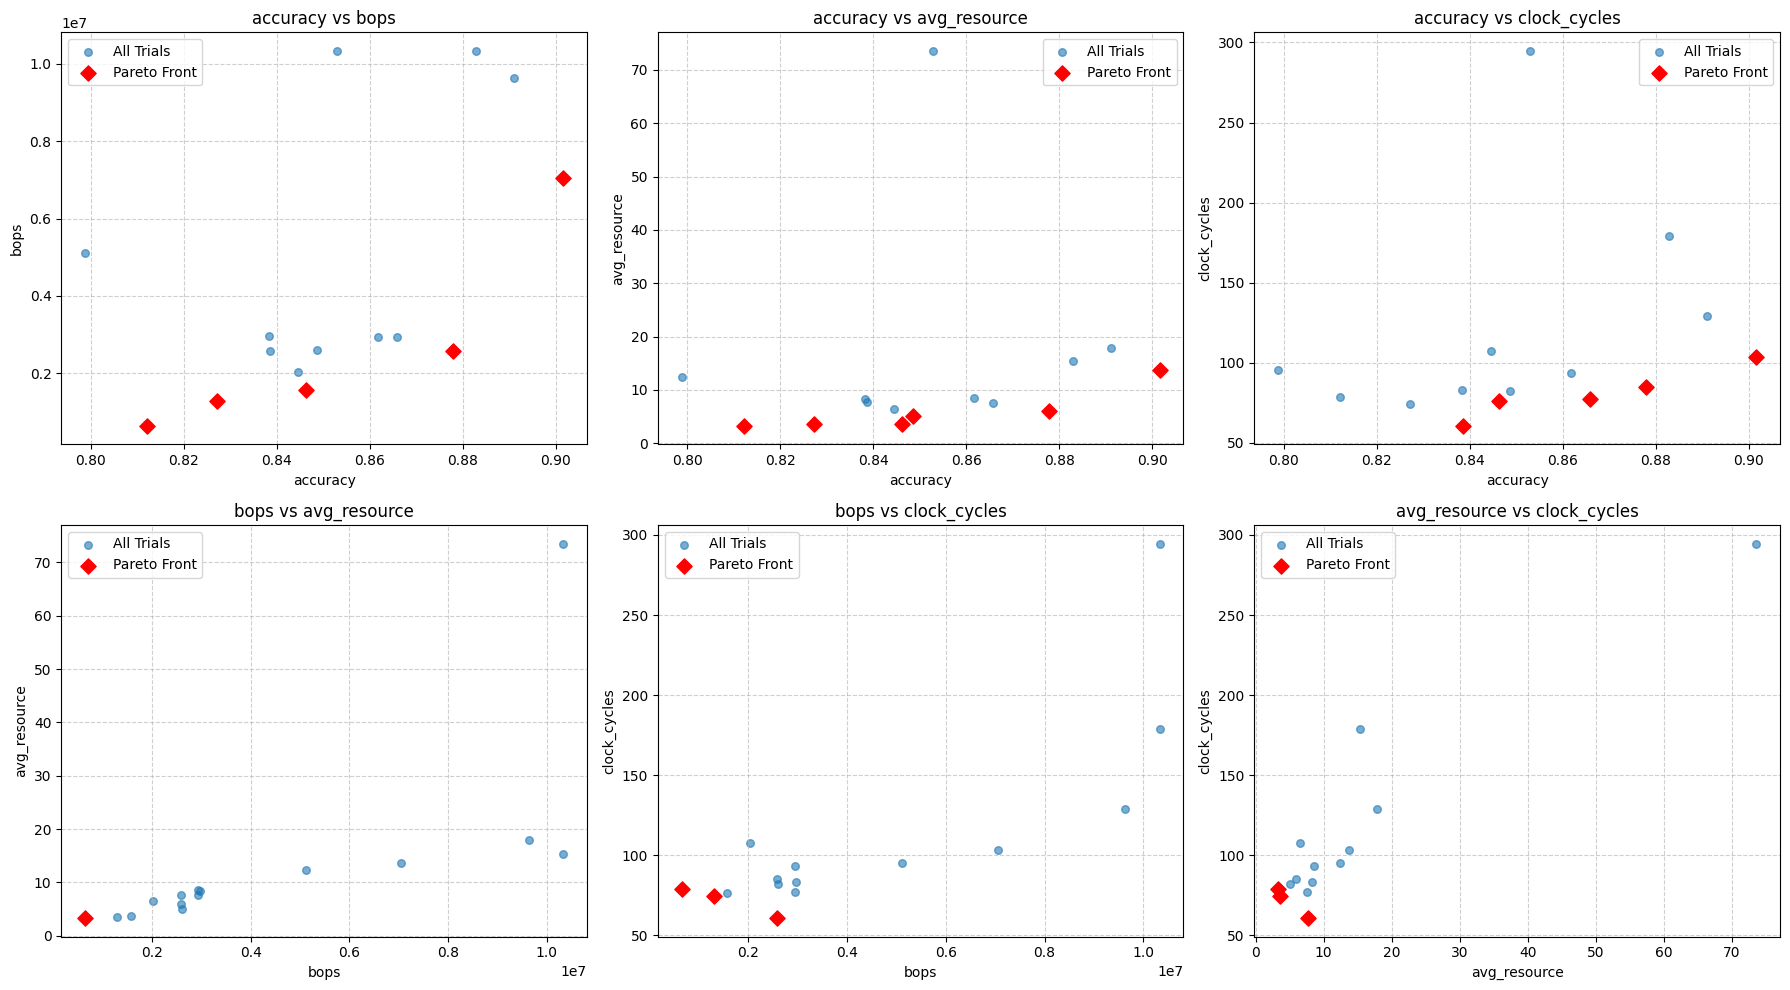


--- Generating 3D Pareto Front Heatmap ---
3D Pareto front plot saved to ./results/mlp_hw_search_tutorial/pareto_front_3d.html



MLP search plots saved to: ./results/mlp_hw_search_tutorial


In [4]:
# --- Analyze Results for Part 1 ---
print("\n" + "="*50)
print("ANALYZING MLP HARDWARE-AWARE RESULTS")
print("="*50)

results_df_mlp = searcher_mlp.get_results_dataframe()

if not results_df_mlp.empty:
    print("\nMLP Search Summary:")
    print(f"Total trials: {len(results_df_mlp)}")
    print(f"Best Accuracy: {results_df_mlp['accuracy'].max():.4f}")
    
    print("\n--- Visualizing Hardware-Aware Pareto Fronts ---")
    plot_pareto_fronts(results_df_mlp, OBJECTIVE_INFO_HW, save_dir=searcher_mlp.results_dir)
    
    if len(OBJECTIVE_NAMES_HW) >= 4:
        print("\n--- Generating 3D Pareto Front Heatmap ---")
        plot_3d_pareto_front_heatmap(results_df_mlp, OBJECTIVE_INFO_HW, save_dir=searcher_mlp.results_dir)
    
    print(f"\nMLP search plots saved to: {searcher_mlp.results_dir}")
else:
    print("MLP search did not yield any results.")



In [10]:
# ## Part 2: Hybrid Architecture Search
#
# Now we'll use the block-based search to find novel hybrid architectures. Since hardware estimators may not be accurate for these arbitrary structures, we will focus our optimization on two key objectives: **performance (accuracy)** and **computational cost (BOPs)**.

# %%
# --- Configuration for Part 2 ---
N_TRIALS_HYBRID = 15
EPOCHS_HYBRID = 15
SUBSET_SIZE_HYBRID = 20000
RESULTS_DIR_HYBRID = "./results/hybrid_search_tutorial"
SEARCH_SPACE_PATH = 'hybrid_search_space.yaml'

# --- Objectives for Hybrid Search (Performance vs. Cost) ---
OBJECTIVE_NAMES_HYBRID = ['bops', 'performance_metric']
MAXIMIZE_FLAGS_HYBRID = [False, True]
OBJECTIVE_INFO_HYBRID = list(zip(OBJECTIVE_NAMES_HYBRID, MAXIMIZE_FLAGS_HYBRID))

os.makedirs(RESULTS_DIR_HYBRID, exist_ok=True)

# %%
# --- Create the YAML configuration file for the hybrid search ---
search_space_yaml = """
search_spaces:
  channel_space: [8, 16, 32]
  mlp_width_space: [32, 64, 128]
  kernel_space: [1, 3, 5]
  act_space: ["ReLU", "GELU"]
  norm_space: [null, "batch"]
  block_types: ["Conv", "MLP", "None", "ConvAttn"]
  # block_types: ["Conv", "MLP", "None"]
hyperparameters:
  num_blocks: 4
  initial_img_size: 11
  output_dim: 10
"""
with open(SEARCH_SPACE_PATH, 'w') as f:
    f.write(search_space_yaml)
print(f"Created search space configuration file: {SEARCH_SPACE_PATH}")


Created search space configuration file: hybrid_search_space.yaml


In [11]:
# --- Run the Hybrid Search (Simple Method) ---
print("\n" + "="*50)
print("Running Part 2: Hybrid Architecture Search...")
print("="*50)

with open(SEARCH_SPACE_PATH, 'r') as f:
    config = yaml.safe_load(f)
search_space_simple = config.get('search_spaces', {})
search_space_simple.update(config.get('hyperparameters', {}))

searcher_simple = GlobalSearchTF(
    results_dir=RESULTS_DIR_HYBRID + "_simple"
)
searcher_simple.search_space = search_space_simple

study_simple = searcher_simple.run_search(
    model_type='block',
    n_trials=N_TRIALS_HYBRID,
    epochs=EPOCHS_HYBRID,
    dataset='mnist',
    subset_size=SUBSET_SIZE_HYBRID,
    resize_val=searcher_simple.search_space.get('initial_img_size', 11),
    objectives=OBJECTIVE_NAMES_HYBRID,
    maximize_flags=MAXIMIZE_FLAGS_HYBRID,
    verbose=True
)


Running Part 2: Hybrid Architecture Search...

Starting BLOCK Global Search on MNIST



[I 2025-08-28 11:04:00,172] A new study created in memory with name: no-name-dfc0a321-620b-4ebe-a3bd-786a09db1f7c


Data loaded and preprocessed:
  Resize: 11x11
  x_train shape: (20000, 11, 11, 1), x_val shape: (10000, 11, 11, 1)
  y_train shape: (20000,), y_val shape: (10000,)


[I 2025-08-28 11:04:10,425] Trial 0 finished with values: [0.8561000227928162, 58458112.0] and parameters: {'b0': 'ConvAttn', 'b1': 'ConvAttn', 'b2': 'MLP', 'b3': 'MLP', 'b2_MLP_units': 2, 'b2_MLP_act': 'ReLU', 'b2_MLP_norm': 'batch', 'b3_MLP_units': 2, 'b3_MLP_act': 'ReLU', 'b3_MLP_norm': 'batch', 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'GELU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}.


Trial 0: Accuracy=0.8561, BOPs=58458112


...

Trial 12: Accuracy=0.9109, BOPs=50724864


[I 2025-08-28 11:07:23,596] Trial 13 finished with values: [0.8510000109672546, 22626304.0] and parameters: {'b0': 'None', 'b1': 'ConvAttn', 'b2': 'Conv', 'b3': 'Conv', 'b2_Conv_channels_0': 1, 'b2_Conv_channels_1': 2, 'b2_Conv_kernels_0': 5, 'b2_Conv_kernels_1': 3, 'b2_Conv_acts_0': 'GELU', 'b2_Conv_acts_1': 'ReLU', 'b2_Conv_norms_0': None, 'b2_Conv_norms_1': 'batch', 'b3_Conv_channels_0': 0, 'b3_Conv_channels_1': 0, 'b3_Conv_kernels_0': 3, 'b3_Conv_kernels_1': 5, 'b3_Conv_acts_0': 'GELU', 'b3_Conv_acts_1': 'GELU', 'b3_Conv_norms_0': None, 'b3_Conv_norms_1': None, 'MLP_Head_width_0': 0, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'ReLU', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': 'batch'}.


Trial 13: Accuracy=0.8510, BOPs=22626304


[I 2025-08-28 11:07:44,967] Trial 14 finished with values: [0.8794999718666077, 142442496.0] and parameters: {'b0': 'Conv', 'b1': 'MLP', 'b2': 'MLP', 'b3': 'MLP', 'b0_Conv_channels_0': 2, 'b0_Conv_channels_1': 1, 'b0_Conv_kernels_0': 5, 'b0_Conv_kernels_1': 1, 'b0_Conv_acts_0': 'ReLU', 'b0_Conv_acts_1': 'ReLU', 'b0_Conv_norms_0': 'batch', 'b0_Conv_norms_1': None, 'b1_MLP_units': 2, 'b1_MLP_act': 'GELU', 'b1_MLP_norm': None, 'b2_MLP_units': 1, 'b2_MLP_act': 'ReLU', 'b2_MLP_norm': 'batch', 'b3_MLP_units': 2, 'b3_MLP_act': 'ReLU', 'b3_MLP_norm': None, 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}.


Trial 14: Accuracy=0.8795, BOPs=142442496

CSV results saved to ./results/hybrid_search_tutorial_simple/block_search_results.csv

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 1):
  Values: {'bops': 0.14000000059604645, 'performance_metric': 63512576.0}
  Params: {'b0': 'Conv', 'b1': 'MLP', 'b2': 'None', 'b3': 'Conv', 'b0_Conv_channels_0': 0, 'b0_Conv_channels_1': 0, 'b0_Conv_kernels_0': 5, 'b0_Conv_kernels_1': 1, 'b0_Conv_acts_0': 'GELU', 'b0_Conv_acts_1': 'GELU', 'b0_Conv_norms_0': None, 'b0_Conv_norms_1': 'batch', 'b1_MLP_units': 2, 'b1_MLP_act': 'ReLU', 'b1_MLP_norm': None, 'MLP_Head_width_0': 0, 'MLP_Head_width_1': 2, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': None}

Rank 2 (Trial 3):
  Values: {'bops': 0.5644999742507935, 'performance_metric': 76185600.0}
  Params: {'b0': 'ConvAttn', 'b1': 'Conv', 'b2': 'ConvAttn', 'b3': 'ConvAttn', 'b1_Conv_channels_0': 2, 'b1_Conv_chann


ANALYZING AND VISUALIZING HYBRID RESULTS
   trial  performance_metric      bops  \
0      0              0.8561  58458112   
1      1              0.1400  63512576   
2      2              0.8733  25362432   
3      3              0.5645  76185600   
4      4              0.3303  16809984   

                                              params  
0  {'b0': 'ConvAttn', 'b1': 'ConvAttn', 'b2': 'ML...  
1  {'b0': 'Conv', 'b1': 'MLP', 'b2': 'None', 'b3'...  
2  {'b0': 'MLP', 'b1': 'Conv', 'b2': 'ConvAttn', ...  
3  {'b0': 'ConvAttn', 'b1': 'Conv', 'b2': 'ConvAt...  
4  {'b0': 'MLP', 'b1': 'None', 'b2': 'None', 'b3'...  

Hybrid Search Results Summary:
Total trials completed: 15
Best Accuracy: 0.9262
Lowest BOPs: 15761408

Top 5 Hybrid Architectures by Performance:
    trial  performance_metric       bops  \
8       8              0.9262  415268864   
10     10              0.9255   85737472   
7       7              0.9132  298745856   
12     12              0.9109   50724864   
5       

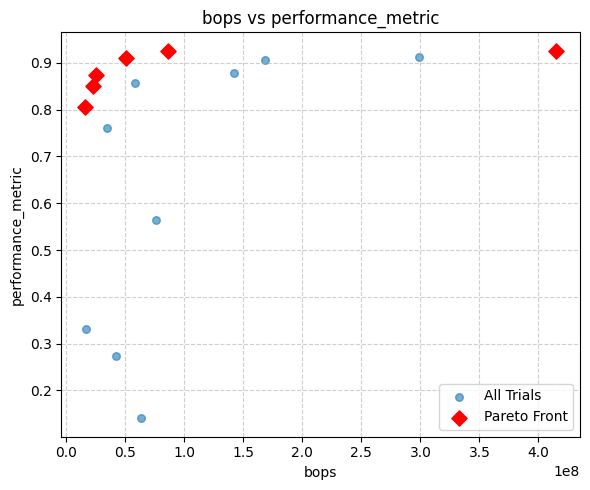


All plots and results saved to: ./results/hybrid_search_tutorial_simple


In [12]:
# ## Analyzing the Hybrid Search Results
#
# For the hybrid search, we analyze the direct trade-off between model performance and its computational cost (BOPs). The Pareto front here will show us which architectures give the best accuracy for a given computational budget.

# %%
print("\n" + "="*50)
print("ANALYZING AND VISUALIZING HYBRID RESULTS")
print("="*50)

results_df_hybrid = pd.DataFrame(searcher_simple.results)
print(results_df_hybrid.head())

if not results_df_hybrid.empty:
    # Display basic statistics
    print("\nHybrid Search Results Summary:")
    print(f"Total trials completed: {len(results_df_hybrid)}")
    print(f"Best Accuracy: {results_df_hybrid['performance_metric'].max():.4f}")
    print(f"Lowest BOPs: {results_df_hybrid['bops'].min()}")

    print("\nTop 5 Hybrid Architectures by Performance:")
    print(results_df_hybrid.sort_values('performance_metric', ascending=False).head())

    # --- Visualize the Pareto Fronts (Accuracy vs BOPs) ---
    print("\n--- Generating Pareto Front Plots for Hybrid Search ---")

    # Generate and display the 2D Pareto front plots
    plot_pareto_fronts(results_df_hybrid, OBJECTIVE_INFO_HYBRID, save_dir=searcher_simple.results_dir)

    print(f"\nAll plots and results saved to: {searcher_simple.results_dir}")
else:
    print("Hybrid search did not yield any results to analyze.")

